In [46]:

import numpy as np
import matplotlib.pyplot as plt
import torch

In [20]:

# Cell 0 — CONFIG
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2
import sys, os
from dotenv import load_dotenv
if sys.platform == "win32":
    project_root = Path(r"F:/MScPROJECT_LOCAL")
else:
    _linux_candidates = [Path("/knuckles_drive"), Path("/workspaces/MScPROJECT_LOCAL")]
    for _candidate in _linux_candidates:
        if _candidate.exists():
            project_root = _candidate
            break
    else:
        raise FileNotFoundError(f"None of the known project_root paths exist: {_linux_candidates}")
load_dotenv(project_root / ".env")

FRAME_NAME_FMT = "{:04d}.jpg"

case_name = "07_Tropea_cafe"
experiment = "cat_04"
asset_name = f"{case_name}_{experiment}"
from A_Config import set_case
set_case(case_name, experiment)

case_dir     = project_root / "Data" / case_name
frames_for_recon   = case_dir   / "020_frames_for_recon" / experiment 
VGGT_O_output_dir   = case_dir   /"035_VGGT_O_output"/experiment
print(VGGT_O_output_dir)
#Load up the recons
from F_transforms_alignments import umeyama_align, recon_to_recon_transform, combine_transforms
from B_VGGT_O_shards import discover_vggt_omega_shards
shards = discover_vggt_omega_shards(VGGT_O_output_dir)
from E_post_recon_processing import Reconstruction
recons = [Reconstruction.load(frames_for_recon, npz_path, FRAME_NAME_FMT, frame_range=(start, end))
                for start, end, npz_path in shards ]



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_04


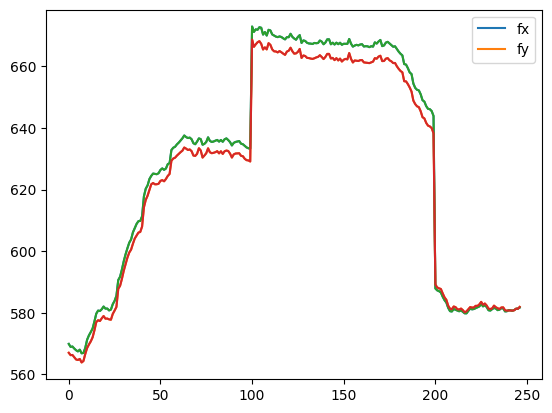

: 

In [ ]:
fx = torch.cat([recons[i].preds["intrinsic"][:, 0, 0].cpu() for i in range(len(recons))])
fy = torch.cat([recons[i].preds["intrinsic"][:, 1, 1].cpu() for i in range(len(recons))])
plt.plot(fx, label="fx")
plt.plot(fy, label="fy")
plt.legend()

plt.plot(fx)
plt.plot(fy)



Iwalk forwards for about 200 frames, so the recon machine thinks I'm zoomingin. 